# Model Project


## 1. A consumer with two nests

### 1.1 The problem in nested budget shares

##### Approach for Section 1.1

The consumer's problem is originally stated in quantities $(x_1, x_2, x_3)$
subject to the linear budget constraint

$$
p_1 x_1 + p_2 x_2 + p_3 x_3 = I,
$$

which a box-constrained solver like L-BFGS-B can't handle directly. Section
1.1 reparametrizes the choice into two numbers confined to $[0,1]$: $s_1$,
the share of income spent on food, and $w$, the share of the remaining
travel budget spent on the bus. The three budget shares then follow
automatically as

$$
s_1, \qquad s_2 = (1 - s_1) w, \qquad s_3 = (1 - s_1)(1 - w),
$$

which always sum to one, so the budget constraint holds for any choice in
the unit square — turning the constrained problem into a simple box
$[0,1] \times [0,1]$, exactly what L-BFGS-B takes as bounds, with no
penalty terms needed.

This mapping (`shares` and `quantities`) is already implemented in
`Consumer.py`, so our job is to understand why it works (linking to the
reparametrization idea from section 6.4 of the optimization lecture) and to
build the utility side of the problem on top of it:

- `utility(x1, x2, x3)` implements the nested CES formula

$$
x_B = \left[\beta x_2^{\rho_B} + (1-\beta) x_3^{\rho_B}\right]^{\frac{1}{\rho_B}},
\qquad
u(x_1, x_2, x_3) = \left[\alpha x_1^{\rho_A} + (1-\alpha) x_B^{\rho_A}\right]^{\frac{1}{\rho_A}},
$$

  combining goods 2 and 3 into the travel composite $x_B$ first, and then
  combining that with good 1.

- `value_of_choice(s1, w)` turns the nested shares into quantities using
  the given `quantities()` function and passes them to `utility()`, giving
  the objective that `solve_grid` and `solve` will later maximize.

In short, 1.1 sets up *what* is being maximized as a function of $(s_1, w)$,
not yet *how* it gets solved.

In [44]:
# Following code is from Consumer.py - We have added our own code when stated in the comments

from types import SimpleNamespace

import numpy as np

from scipy import optimize

class ConsumerClass:
    """ a consumer with nested CES preferences over three goods

    Good 1 is food. Goods 2 and 3 are bus trips and train trips, and they sit
    together in a nest.

    The problem is written in *nested* budget shares, in the same two steps as
    the nests themselves:

        s1 = the share of income spent on food
        w  = the share of the remaining (travel) budget spent on the bus

    so that s2 = (1-s1)*w and s3 = (1-s1)*(1-w). Any (s1,w) in the unit square
    is a possible choice, and every possible choice is in the unit square, so
    the constraint set is exactly the box that L-BFGS-B takes as `bounds`.

    """

    def __init__(self,par=None):

        # a. setup
        self.setup()

        # b. update parameters
        if not par is None:
            for k,v in par.items():
                self.par.__dict__[k] = v

    def setup(self):
        """ set the baseline parameters """

        par = self.par = SimpleNamespace()
        sol = self.sol = SimpleNamespace()

        # a. preference weights
        par.alpha = 0.60 # weight on food
        par.beta = 0.50 # weight on the bus

        # b. substitution
        par.sigma_A = 0.80 # between food and travel (upper nest)
        par.sigma_B = 0.40 # between bus and train (lower nest)

        # c. prices and income
        par.p1 = 1.0 # price of food
        par.p2 = 1.0 # price of a bus trip
        par.p3 = 1.5 # price of a train trip
        par.I = 10.0 # income

        # d. numerical settings
        par.s_min = 1e-12 # smallest quantity allowed in .ces(), see the note there

    def __str__(self):
        """ print the parameters """

        par = self.par

        lines = ['ConsumerClass']
        lines.append(f'  alpha = {par.alpha:.4f}, beta = {par.beta:.4f}')
        lines.append(f'  sigma_A = {par.sigma_A:.4f}, sigma_B = {par.sigma_B:.4f}')
        lines.append(f'  p1 = {par.p1:.4f}, p2 = {par.p2:.4f}, p3 = {par.p3:.4f}')
        lines.append(f'  I = {par.I:.4f}')

        return '\n'.join(lines)

    ###################
    # 1. the CES nest #
    ###################

    def ces(self,z1,z2,w,sigma):
        """ the CES aggregate of two inputs

        Computes (w*z1**rho + (1-w)*z2**rho)**(1/rho) with rho = 1-1/sigma.

        The inputs are floored at par.s_min, because z**rho is not defined for
        z = 0 when rho < 0, and the corners of the unit square do give zeros.

        Note on the size of par.s_min. It must be *far* below the step that
        L-BFGS-B uses to estimate the gradient, which is `eps` and about 1e-8 by
        default. Otherwise both z and z+eps get floored to the same number near a
        bound, utility comes out exactly equal in the two points, the estimated
        gradient is zero, and the solver stops on the bound and stays there. With
        s_min = 1e-8 that really happens: the answers in section 4 for high tax
        rates come out as zero revenue. 1e-12 is small enough to be invisible and
        large enough to keep z**rho from overflowing.

        Args:

            z1 (float or ndarray): first input
            z2 (float or ndarray): second input
            w (float): weight on the first input
            sigma (float): substitution parameter, must not be 1

        Returns:

            (float or ndarray): the CES aggregate

        """

        par = self.par

        assert not np.isclose(sigma,1.0), 'sigma = 1 gives rho = 0 and a division by zero'

        z1 = np.maximum(z1,par.s_min)
        z2 = np.maximum(z2,par.s_min)

        rho = 1-1/sigma

        return (w*z1**rho + (1-w)*z2**rho)**(1/rho)

    def utility(self,x1,x2,x3):
        """ nested CES utility of a bundle of quantities

        Two steps: first combine goods 2 and 3 into the travel composite, then
        combine good 1 and the composite into utility. Use .ces() for both.

        Args:

            x1 (float or ndarray): quantity of good 1
            x2 (float or ndarray): quantity of good 2
            x3 (float or ndarray): quantity of good 3

        Returns:

            (float or ndarray): utility

        """

        par = self.par

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE TO GENERATE THE TRAVEL COMPOSITE AND THE UTILITY 
        #pass

        par = self.par
        
        xB = self.ces(x2, x3, par.beta, par.sigma_B)
                
        u = self.ces(x1, xB, par.alpha, par.sigma_A)

        return u

#-------------------------------------------------------------------------------------#

    ###############################
    # 2. the nested budget shares #
    ###############################

    def shares(self,s1,w):
        """ the three budget shares implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (tuple): the three budget shares, which always sum to one

        """

        return s1,(1-s1)*w,(1-s1)*(1-w)

    def quantities(self,s1,w):
        """ the quantities implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (tuple): the three quantities

        """

        par = self.par

        s1,s2,s3 = self.shares(s1,w)

        return s1*par.I/par.p1, s2*par.I/par.p2, s3*par.I/par.p3

    def value_of_choice(self,s1,w):
        """ utility of the bundle implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (float or ndarray): utility

        """

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE. INSTEAD OF CHOOSING QUANTITIES, WE CHOOSE BUDGET SHARES. 

        #pass
        x1, x2, x3 = self.quantities(s1, w)
        u = self.utility(x1, x2, x3)

        return u
#-------------------------------------------------------------------------------------#

    def objective(self,s):
        """ minus utility, for a minimizer

        Nothing else is needed: the bounds are the whole constraint.

        Args:

            s (ndarray): array of length 2 with (s1,w)

        Returns:

            (float): minus utility

        """

        return -self.value_of_choice(s[0],s[1])

    #################
    # 3. solving it #
    #################

    def solve_grid(self,N=200,do_print=True):
        """ solve by a 2-dimensional grid search over the nested shares

        Every point of the unit square is a possible choice, so there is nothing
        to mask out here -- a plain np.argmax will do.

        Args:

            N (int): number of grid points for each variable
            do_print (bool): print the solution

        Returns:

            (SimpleNamespace): the grids, the utility values and the best point

        """

        par = self.par
        opt = SimpleNamespace()

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE. 

        # a. the two grids
        #pass
        s1_vec = np.linspace(0, 1, N)
        w_vec = np.linspace(0, 1, N)
    
        opt.s1_grid, opt.w_grid = np.meshgrid(
                s1_vec, w_vec, indexing='ij'
             )

        # b. utility in every grid point
        #pass
        opt.u_grid = self.value_of_choice(
                    opt.s1_grid,
                    opt.w_grid
                )

        # c. the best point
        #pass
        idx = np.unravel_index(
                   np.argmax(opt.u_grid),
                   opt.u_grid.shape
                )
        
        opt.s1 = opt.s1_grid[idx]
        opt.w = opt.w_grid[idx]
        
        opt.s2 = (1 - opt.s1) * opt.w
        opt.s3 = (1 - opt.s1) * (1 - opt.w)
        
        opt.u = opt.u_grid[idx]
    

        # d. results
        # opt.s1, opt.w, opt.s2, opt.s3, opt.u
        # opt.s1_grid, opt.w_grid, opt.u_grid (needed for the figures)

        return opt

#-------------------------------------------------------------------------------------#

    def solve(self,s0=None,do_print=True,**kwargs):
        """ solve with L-BFGS-B

        The bounds are ((0,1),(0,1)) -- the whole constraint set.

        Args:

            s0 (ndarray): starting guess for (s1,w)
            do_print (bool): print the solution
            kwargs: passed on to optimize.minimize, e.g. options={'ftol':1e-10}

        Returns:

            (SimpleNamespace): the solution and the convergence path

        """

        par = self.par
        opt = SimpleNamespace()

        # a. starting guess
        if s0 is None: s0 = np.array([0.5,0.5])
        s0 = np.asarray(s0,dtype=float)

        # b. record the path with a callback
        path = [s0.copy()]

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE
        # c. minimize
        #pass
        res = optimize.minimize(
               self.objective,
               s0,
               method='L-BFGS-B',
               bounds=((0,1),(0,1)),
               callback=lambda sk: path.append(sk.copy()),
               **kwargs
            )

        # d. results
        # opt.s1, opt.w, opt.s2, opt.s3, opt.u, opt.path, opt.res
        opt.s1 = res.x[0]
        opt.w = res.x[1]
        opt.s2 = (1 - opt.s1) * opt.w
        opt.s3 = (1 - opt.s1) * (1 - opt.w)
        opt.u = -res.fun
        opt.path = path
        opt.res = res

        return opt

#-------------------------------------------------------------------------------------#

### 1.2 Calibration


##### Approach for Section 1.2

Section 1.2 does not require new code, only running the existing model under
two calibrations that differ solely in $\sigma_B$: $\sigma_B = 0.40$ (bus and
train as complements) versus $\sigma_B = 3.00$ (substitutes), with all other
parameters held fixed. Since `ConsumerClass` already accepts a `par`
dictionary that overwrites only the given keys, the second calibration costs
one extra line,

```python
model_substitutes = ConsumerClass(par={'sigma_B': 3.0})
```

and every later step (solving, printing, plotting) can loop over both models
instead of duplicating code.


In short, the first model uses the parameter sigma_B = 0.40.
The second model changes to sigma_B = 3.0. While all the other parameters remain the same.

In [45]:
# Calibration 1: Complements
model_comp = ConsumerClass(par={'sigma_B': 0.4})

# Calibration 2: Substitutes 
model_sub = ConsumerClass(par={'sigma_B': 3.0})

We can now check wheather the calibrations are correct

In [46]:
print("Complements:")
print(model_comp)

print("\nSubstitutes:")
print(model_sub)

Complements:
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000

Substitutes:
ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


The model is solved for both calibrations. The two calibrations are identical except for the substituion parameter between bus and train, sigma_B. In the first calibration, we have sigma_B = 0.40, which means the bus and train are complements. In the second calibration, sigma_B = 3.00, so bus and train are substitutes. Note that the second calibration is produced by changing the value of sigma_B. While all the other preference, parameters, prices, and income remain unchanged.

### 1.3 How do you know your answer is right?

##### Approach for section 1.3
Since there is no formula for the solution of this model, we cannot look the answer up. Instead we can check the answer with two different approaches:

1. Is the answer possible? All three shares should be strictly between 0 and 1 and
sum to one, and all three quantities should be positive.


2. Do two different methods agree? In section 2 you solve the same problem
twice.

## 3 Relative prices and demand

### 3.1 Train prices, budget shares and quantities

We now let the price of train trips, p3, vary from 0.5 to 3.0, while p1, p2 and income are held fixed. We solve the model for each value of p3 for both the complements and substitutes calibration.

We first import the packages and functions needed for the analysis.

In [47]:
from types import SimpleNamespace

import numpy as np

from scipy import optimize

import matplotlib.pyplot as plt

from Consumer import ConsumerClass

We run the notebook containing the consumer model so that the model can be used in the analysis below. The output is suppressed to avoid repeating results from the previous part.

We create a grid of train prices from 0.5 to 3.0 and define the two calibrations used in the analysis.

In [48]:
p3_vec = np.linspace(0.5, 3.0, 100)

model = ConsumerClass()
model_sub = ConsumerClass(par={'sigma_B': 3.0})

First, we solve the model for the complements calibration. For each value of `p3`, we store the optimal budget shares and the corresponding quantities.

In [49]:
# Complements

s1_comp = []
s2_comp = []
s3_comp = []

x1_comp = []
x2_comp = []
x3_comp = []

for p3 in p3_vec:

    model.par.p3 = p3
    sol = model.solve()

    s1_comp.append(sol.s1)
    s2_comp.append(sol.s2)
    s3_comp.append(sol.s3)

    x1, x2, x3 = model.quantities(sol.s1, sol.w)

    x1_comp.append(x1)
    x2_comp.append(x2)
    x3_comp.append(x3)


We repeat the same procedure for the substitutes calibration. The only difference between the two models is the value of `sigma_B`.


In [50]:
# Substitutes

s1_sub = []
s2_sub = []
s3_sub = []

x1_sub = []
x2_sub = []
x3_sub = []

for p3 in p3_vec:

    model_sub.par.p3 = p3
    sol_sub = model_sub.solve()

    s1_sub.append(sol_sub.s1)
    s2_sub.append(sol_sub.s2)
    s3_sub.append(sol_sub.s3)

    x1, x2, x3 = model_sub.quantities(sol_sub.s1, sol_sub.w)

    x1_sub.append(x1)
    x2_sub.append(x2)
    x3_sub.append(x3)

Finally, we plot the budget shares and quantities against the train price for both calibrations. This makes it possible to compare how demand changes when `p3` increases.

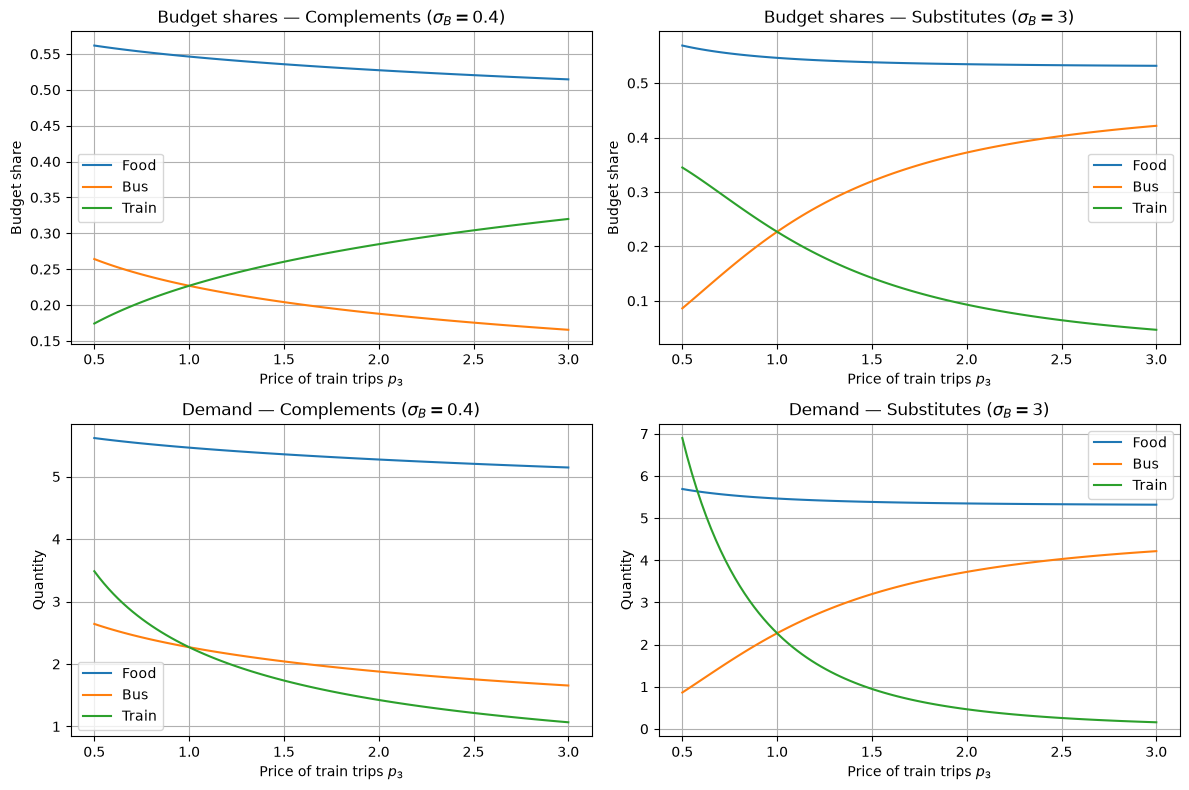

In [51]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Budget shares - Complements
ax[0,0].plot(p3_vec, s1_comp, label='Food')
ax[0,0].plot(p3_vec, s2_comp, label='Bus')
ax[0,0].plot(p3_vec, s3_comp, label='Train')

ax[0,0].set_title('Budget shares — Complements ($\\sigma_B=0.4$)')
ax[0,0].set_xlabel('Price of train trips $p_3$')
ax[0,0].set_ylabel('Budget share')
ax[0,0].legend()
ax[0,0].grid(True)


# Budget shares - Substitutes
ax[0,1].plot(p3_vec, s1_sub, label='Food')
ax[0,1].plot(p3_vec, s2_sub, label='Bus')
ax[0,1].plot(p3_vec, s3_sub, label='Train')

ax[0,1].set_title('Budget shares — Substitutes ($\\sigma_B=3$)')
ax[0,1].set_xlabel('Price of train trips $p_3$')
ax[0,1].set_ylabel('Budget share')
ax[0,1].legend()
ax[0,1].grid(True)


# Quantities - Complements
ax[1,0].plot(p3_vec, x1_comp, label='Food')
ax[1,0].plot(p3_vec, x2_comp, label='Bus')
ax[1,0].plot(p3_vec, x3_comp, label='Train')

ax[1,0].set_title('Demand — Complements ($\\sigma_B=0.4$)')
ax[1,0].set_xlabel('Price of train trips $p_3$')
ax[1,0].set_ylabel('Quantity')
ax[1,0].legend()
ax[1,0].grid(True)


# Quantities - Substitutes
ax[1,1].plot(p3_vec, x1_sub, label='Food')
ax[1,1].plot(p3_vec, x2_sub, label='Bus')
ax[1,1].plot(p3_vec, x3_sub, label='Train')

ax[1,1].set_title('Demand — Substitutes ($\\sigma_B=3$)')
ax[1,1].set_xlabel('Price of train trips $p_3$')
ax[1,1].set_ylabel('Quantity')
ax[1,1].legend()
ax[1,1].grid(True)

plt.tight_layout()
plt.show()

The figures show that the response to a higher train price differs substantially between the two calibrations. The following questions examine these differences in more detail.

### 3.2 Train budget share

For complements, $\sigma_B = 0.4 < 1$. From the figure, the train budget share increases as `p3` increases. Even though the consumer buys fewer train trips, the higher price means that a larger share of the budget is spent on train trips.

For substitutes, $\sigma_B = 3 > 1$. Here, the train budget share decreases as `p3` increases. Since bus and train are substitutes, the consumer shifts expenditure away from the more expensive train and towards bus trips.

Therefore:
- Complements: higher `p3` increases the train budget share.
- Substitutes: higher `p3` decreases the train budget share.

### 3.3 Bus trips

For complements, $\sigma_B = 0.4$. When train tickets become more expensive, the consumer buys fewer train trips. Since bus and train are complements, the demand for bus trips also falls.

Therefore:

$p_3 \uparrow \Rightarrow x_3 \downarrow \Rightarrow x_2 \downarrow$

For substitutes, $\sigma_B = 3$. When train tickets become more expensive, the consumer substitutes away from train trips and towards bus trips.

Therefore:

$p_3 \uparrow \Rightarrow x_3 \downarrow \Rightarrow x_2 \uparrow$

The main difference is therefore that bus demand falls under complements, but increases under substitutes.

### 3.4 Demand for food

To compare the effect on food and bus demand, we calculate the percentage change in quantities between `p3 = 0.5` and `p3 = 3.0`.

In [52]:
food_change_comp = (
    (x1_comp[-1] - x1_comp[0])
    / x1_comp[0] * 100
)

bus_change_comp = (
    (x2_comp[-1] - x2_comp[0])
    / x2_comp[0] * 100
)

food_change_sub = (
    (x1_sub[-1] - x1_sub[0])
    / x1_sub[0] * 100
)

bus_change_sub = (
    (x2_sub[-1] - x2_sub[0])
    / x2_sub[0] * 100
)

print("Complements:")
print("Food:", food_change_comp, "%")
print("Bus:", bus_change_comp, "%")

print("\nSubstitutes:")
print("Food:", food_change_sub, "%")
print("Bus:", bus_change_sub, "%")

Complements:
Food: -8.393018675220478 %
Bus: -37.32920283756819 %

Substitutes:
Food: -6.539495185881841 %
Bus: 388.8347534879367 %


Food demand changes much less than bus demand when the price of train trips increases.

For complements, food demand falls by about 8.4%, while bus demand falls by about 37.3%.

For substitutes, food demand falls by about 6.5%, while bus demand increases by about 388.8%.

The effect on bus demand is therefore much stronger than the effect on food demand. This is because bus and train are in the same travel nest, while food is outside the lower bus/train nest. A change in the train price therefore affects bus demand more directly, while food is affected indirectly through the allocation between food and travel.

# 4. Lump-sum taxes and product taxes 

This block imports the packages needed for the analysis. ```numpy``` is used for numerical calculations, ```pandas``` for creating tables, and ```matplotlib``` for plotting the results. ```GovernmentClass``` is imported from ```Government.py``` to apply the different taxes and calculate revenue and utility. The code then defines the five product-tax instruments, the two calibrations, and a grid of 101 tax rates from 0 to 3 that will be used to analyse how tax revenue changes with the tax rate.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Government import GovernmentClass

taxes = {
    "Food": (1,),
    "Bus": (2,),
    "Train": (3,),
    "Bus + train": (2, 3),
    "All goods": (1, 2, 3)
}

calibrations = {
    "Complements": 0.40,
    "Substitutes": 3.00
}

tau_grid = np.linspace(0, 3, 101)

### 4.1. Implementation of the required methods in ```Government.py```

<br>

***The code below is written in the*** ```Government.py``` ***file instead of the first 'pass'.***
<br>
<br>
Finds how much of each good the consumer buys:

```x1, x2, x3 = self.quantities(opt.s1, opt.w)```

<br>
lump-sum tax + tax from good 1 + tax from good 2 + tax from good 3:

``` 
R = (
    par.T
    + par.tau1 * par.p1_pre * x1
    + par.tau2 * par.p2_pre * x2
    + par.tau3 * par.p3_pre * x3
) 
```


<br>



***The code below is written in the*** ```Government.py``` ***file instead of the second 'pass'.***

We are looking specifically at product taxes, so there is no lump-sum tax:
```
T = 0.0
```

Deciding wether a good is taxed. e.g. if ```goods = (1,)``` we tax food. Same goes for goods 2 and 3 (bus and train):
```
tau1 = tau if 1 in goods else 0.0
tau2 = tau if 2 in goods else 0.0
tau3 = tau if 3 in goods else 0.0
```

Applies these tax rates and updates the prices the consumer faces:
```
self.set_taxes(T=T, tau1=tau1, tau2=tau2, tau3=tau3)
```

Solves the consumer's problem with the new taxed prices:
```
opt = self.solve(do_print=False)
```

Calculates the government's total tax revenue from the consumer's choice:
```
R = self.tax_revenue(opt)
```

Saves the consumer's utility from the optimal choice:
```
u = opt.u
```


<br>


***The code below is written in the*** ```Government.py``` ***file instead of the third 'pass'.***

Sets the lump-sum tax to ```T```. No product taxes are applied:
```
self.set_taxes(T=T)
```

Finds the consumer's optimal choice after the lump-sum tax:
```
opt = self.solve(do_print=False)
````

Calculates the government's tax revenue from the lump-sum tax:
```
R = self.tax_revenue(opt)
```

Gets the consumer's utility after the tax:
```
u = opt.u
```


<br>



***The code below is written in the*** ```Government.py``` ***file instead of the fourth 'pass'.***

Creates ```N``` different tax rates between 0 and ```tau_max```:
```
tau_grid = np.linspace(0.0, tau_max, N)
````

Creates an empty array to store the revenue for each tax rate:
```
revenue_grid = np.empty(N)
```

Goes through each tax rate and gives it an index ```i```:
```
for i, tau in enumerate(tau_grid):
````

Calculates the revenue for that tax rate and stores it in ```revenue_grid```:
```
revenue_grid[i] = self.revenue_and_utility(tau, goods)[0]
````

Finds the index where the highest revenue occurs:
```
idx = np.argmax(revenue_grid)
```

Finds the tax rate that gives the highest revenue:
```
tau = tau_grid[idx]
```

Stores the maximum revenue:
```
R = revenue_grid[idx]
```


<br>


***The code below is written in the*** ```Government.py``` ***file instead of the fifth 'pass'.***

Defines a function that takes the tax rate ```tau``` and calculates how far the resulting revenue is from the target revenue:
```
def f(tau):
    R, _ = self.revenue_and_utility(tau, goods)
    return R - R_target
```

Tries to find the tax rate that gives exactly the target revenue using the Brent root-finding method:
```
try:
    res = optimize.root_scalar(
        f,
        bracket=bracket,
        method='brentq'
    )
        tau = res.root
```

If the root-finder cannot find a solution within the specified interval, it catches the error and sets the tax rate to ```np.nan```
```
except ValueError:
        tau = np.nan
```





### 4.2 Revenue as a function of the tax rate

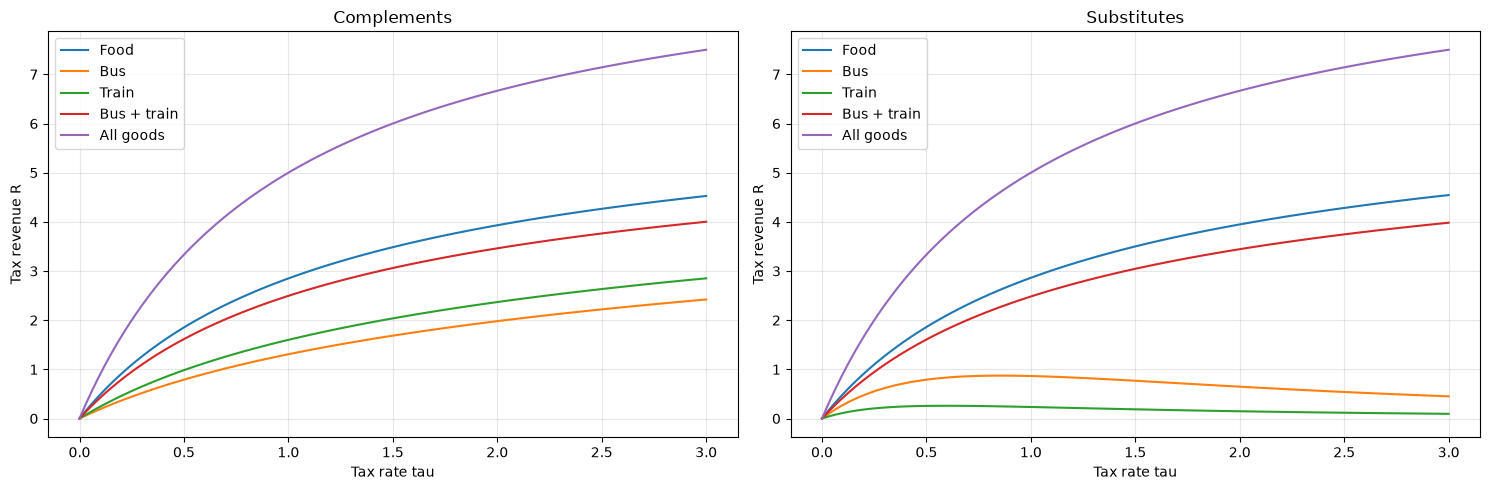

In [54]:
# Create two plots, one for each calibration
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loop over the two calibrations
for ax, (name, sigma_B) in zip(axes, calibrations.items()):
    
    # Create the government model with the given sigma_B
    model = GovernmentClass(par={"sigma_B": sigma_B})

    # Loop over the five different tax instruments
    for label, goods in taxes.items():
        
        # Calculate revenue for each tax rate
        revenue = [model.revenue_and_utility(tau, goods)[0] for tau in tau_grid]
        
        # Plot revenue against the tax rate
        ax.plot(tau_grid, revenue, label=label)

    # Add title and labels to the graph
    ax.set_title(name)
    ax.set_xlabel("Tax rate tau")
    ax.set_ylabel("Tax revenue R")
    
    # Add grid and legend
    ax.grid(alpha=0.3)
    ax.legend()

# Adjust the layout and show the graphs
plt.tight_layout()
plt.show()

### 4.3 Maximum Revenue

In the substitutes plot, the bus and train curves have a maximum (a top). These are the only curves that reach a maximum. In the other examples, all curves continue to increase over the tax-rate range shown.

In [55]:
# Create an empty list to store the results
max_results = []

# Loop over the two calibrations
for name, sigma_B in calibrations.items():
    
    # Create the government model for the calibration
    model = GovernmentClass(par={"sigma_B": sigma_B})

    # Loop over the five tax instruments
    for label, goods in taxes.items():
        
        # Find the tax rate that gives the maximum revenue
        tau_star, R_max = model.max_revenue(
            goods=goods, tau_max=3.0, N=1001
        )
        
        # Store the results
        max_results.append({
            "Calibration": name,
            "Tax": label,
            "Revenue-maximizing tau": tau_star,
            "Maximum revenue": R_max
        })

# Convert the results into a table
max_df = pd.DataFrame(max_results)

# Display the table
display(max_df)

,Calibration,Tax,Revenue-maximizing tau,Maximum revenue
0,Complements,Food,3.000,4.526108
1,Complements,Bus,3.000,2.420563
2,Complements,Train,3.000,2.850957
3,Complements,Bus + train,3.000,4.001854
4,Complements,All goods,3.000,7.500000
5,Substitutes,Food,3.000,4.544876
6,Substitutes,Bus,0.855,0.872144
7,Substitutes,Train,0.594,0.259039
8,Substitutes,Bus + train,3.000,3.982312
9,Substitutes,All goods,3.000,7.500000


**What is the most that a tax on train tickets alone can ever raise in the substitutes calibration?**

For the train tax in the substitutes calibration, the revenue-maximizing tax rate is 0.594, which gives a maximum revenue of 0.259.

### 4.4 Utility against revenue

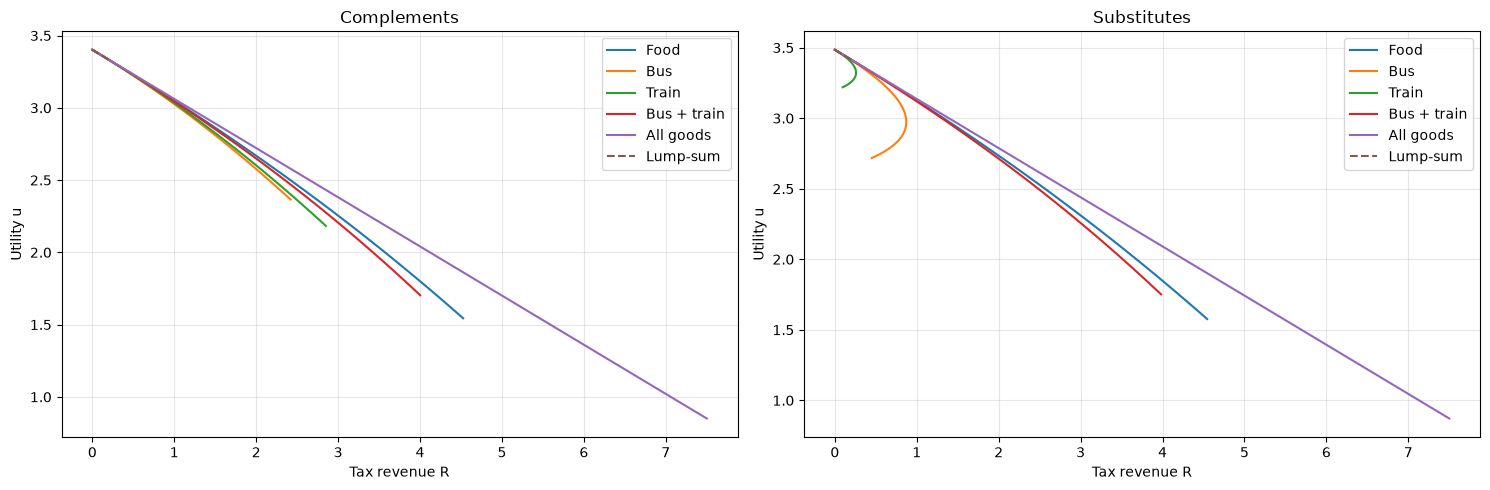

In [56]:
# Create two plots, one for each calibration
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loop over the two calibrations
for ax, (name, sigma_B) in zip(axes, calibrations.items()):

    # Create the government model for the calibration
    model = GovernmentClass(par={"sigma_B": sigma_B})

    # Loop over the five product-tax instruments
    for label, goods in taxes.items():
        revenue, utility = [], []

        # Calculate revenue and utility for each tax rate
        for tau in tau_grid:
            R, u = model.revenue_and_utility(tau, goods)
            revenue.append(R)
            utility.append(u)

        # Plot utility against revenue
        ax.plot(revenue, utility, label=label)

    # Calculate utility for different lump-sum tax levels
    R_lump = np.linspace(0, 0.20, 51)
    u_lump = [model.revenue_and_utility_lump_sum(T)[1] for T in R_lump]

    # Plot the lump-sum tax as a dashed line
    ax.plot(R_lump, u_lump, "--", label="Lump-sum")

    # Add title and axis labels
    ax.set_title(name)
    ax.set_xlabel("Tax revenue R")
    ax.set_ylabel("Utility u")

    # Add grid and legend
    ax.grid(alpha=0.3)
    ax.legend()

# Adjust the layout and show the plots
plt.tight_layout()
plt.show()

Lump-sum tax and taxing all goods are equally cheapest. Taxing all goods raises all prices proportionally, which is equivalent to reducing income through a lump-sum tax. Their curves therefore overlap.

The behavior of narrow taxes (Food, Bus, Train alone) does depend on the calibration. Under substitutes, taxing Bus pushes people onto Train so hard that at some point raising the tax rate further actually reduces revenue — Bus and Train have a peak they can't get past. Under complements, this doesn't happen; revenue just keeps rising as the tax rate increases.

### 4.5 Revenue requirement R = 0.20

In [57]:
### 4.5 Rate that hits R = 0.20 for each instrument

R_target = 0.20
tables = {}

# Loop over the two calibrations
for name, sigma_B in calibrations.items():

    # Create the government model for the calibration
    model = GovernmentClass(par={"sigma_B": sigma_B})

    rows = []
    # Loop over the five product-tax instruments
    for label, goods in taxes.items():

        # Find the tax rate that raises exactly R_target
        tau = model.find_tax_rate(R_target, goods=goods, bracket=(1e-10, 1.0))

        # Utility at that rate
        R, u = model.revenue_and_utility(tau, goods)

        rows.append({"Tax": label, "tau*": tau, "R": R, "Utility": u})

    # Rank by utility: highest utility = cheapest way to raise R_target
    df = pd.DataFrame(rows).sort_values("Utility", ascending=False).reset_index(drop=True)
    df.insert(0, "Rank", range(1, len(df) + 1))
    tables[name] = df

    print(f"=== {name} ===")
    display(df)

=== Complements ===


,Rank,Tax,tau*,R,Utility
0,1,All goods,0.020408,0.2,3.333646
1,2,Food,0.038647,0.2,3.333169
2,3,Bus + train,0.044787,0.2,3.333010
3,4,Train,0.081011,0.2,3.332548
4,5,Bus,0.104215,0.2,3.332260


=== Substitutes ===


,Rank,Tax,tau*,R,Utility
0,1,All goods,0.020408,0.2,3.415402
1,2,Food,0.038454,0.2,3.414919
2,3,Bus + train,0.045049,0.2,3.414744
3,4,Bus,0.069532,0.2,3.412375
4,5,Train,0.236217,0.2,3.395521



**Ranking**
<br>
The instruments are already ranked in the tables, sorted by utility — which is equivalent to ranking by Cost, since Cost is simply the utility gap between each instrument and the best-performing one ("All goods") at the same revenue target R = 0.20. A lower Cost means the instrument gets the consumer closer to what they could have achieved, and therefore ranks higher. 

Under ```Complements```, utilities across all five instruments are close together: the largest gap is between All goods and Bus, at 3.333646 − 3.332260 = 0.001386. Since bus and train are complements, taxing one narrow good doesn't give consumers an easy substitute to switch to, so even the worst instrument stays relatively close to the best.

Under ```Substitutes```, the spread is far wider: the largest gap is between All goods and Train, at 3.415402 − 3.395521 = 0.019881 — roughly 14 times larger than the biggest gap under Complements. Here, taxing a single good gives consumers a close substitute to escape to, which drives up the cost.

**Particular comment on the tax on train tickets:**
<br>
Taxing train tickets is cheap when travel goods are complements (no easy way to dodge the tax) but becomes the worst instrument when travel goods are substitutes, precisely because commuters can simply swap to the untaxed alternative